In [1]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [ ]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state["number"].append(random.randint(0,10))
    state["counter"] += 1

    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["counter"] < 5:
        print("Loop")
        return "loop"   # continue looping
    
    else:
        return "exit"   # Exit the loop



In [10]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")

graph.add_conditional_edges(
    "random",   # Source node
    should_continue,    # Action
    {
        "loop": "random",   # Self-loop back to the same node
        "exit": END     # End the graph
    }

)

graph.set_entry_point("greeting")

app = graph.compile()



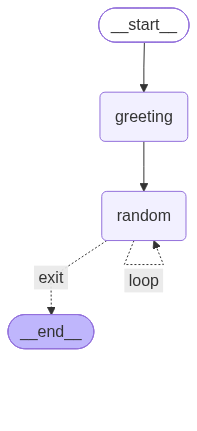

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
app.invoke({"name":"Suresh", "number":[],"counter":-1})

{'name': 'Hi there, Suresh', 'number': [10, 5, 4, 6, 0], 'counter': 5}